In [75]:
# Fish Age Prediction from Otolith Images and Length Data
# Using TensorFlow/Keras

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

# TensorFlow imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check if GPU is available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Num GPUs Available:  0


In [76]:
# Load and explore the dataset
df = pd.read_csv('otolith_labels_converted.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (17, 3)

First few rows:
                                               Image  Age  Length
0  Images_converted\Mubar_104mm_13_13-07-16_TAK_M...   13     104
1  Images_converted\Mubar_107mm_26_09-07-16_TAK_M...   26     107
2  Images_converted\Mubar_195mm_09_03-10-16_MARKE...    9     195
3  Images_converted\Mubar_58mm_09_25-06-16_TAK_MI...    9      58
4  Images_converted\Mubar_77mm_03_08-10-16_TAK_MI...    3      77

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Image   17 non-null     object
 1   Age     17 non-null     int64 
 2   Length  17 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 540.0+ bytes
None

Basic statistics:
              Age      Length
count   17.000000   17.000000
mean    41.235294  143.529412
std     47.167957   51.615305
min      3.000000   58.000000
25%      9.000000  104.000000
50%     

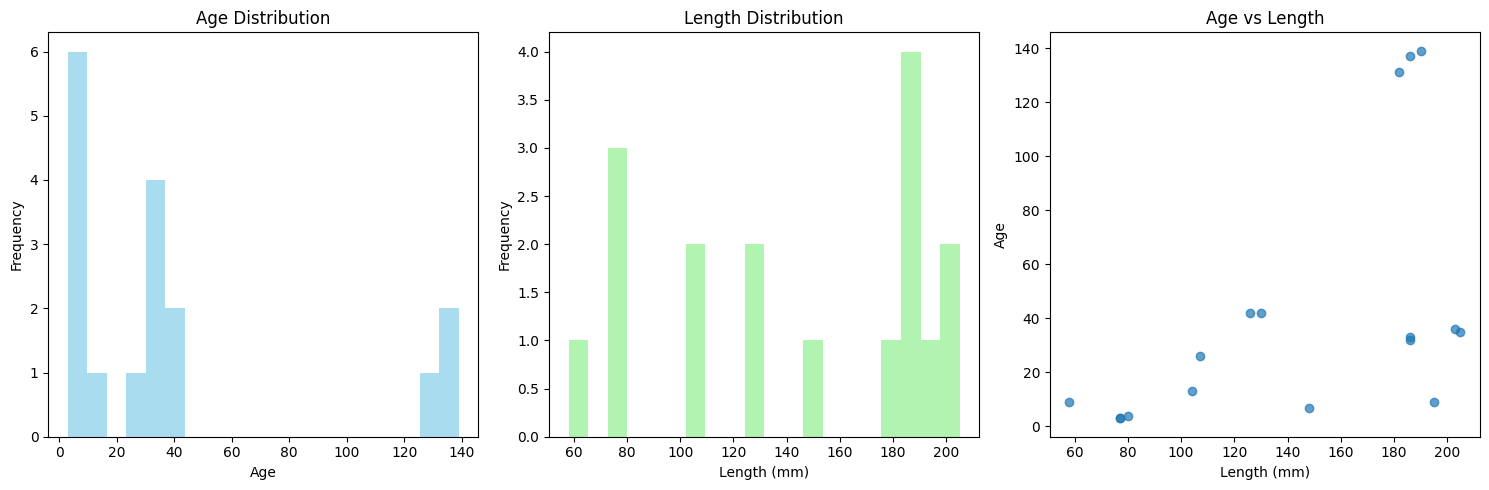

In [77]:
# Visualize the data distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df['Age'], bins=20, alpha=0.7, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(df['Length'], bins=20, alpha=0.7, color='lightgreen')
plt.title('Length Distribution')
plt.xlabel('Length (mm)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.scatter(df['Length'], df['Age'], alpha=0.7)
plt.title('Age vs Length')
plt.xlabel('Length (mm)')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

In [78]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check image paths
print("\nChecking image paths...")
for idx, row in df.iterrows():
    if not os.path.exists(row['Image']):
        print(f"Warning: Image not found - {row['Image']}")

Missing values:
Image     0
Age       0
Length    0
dtype: int64

Checking image paths...


In [79]:
# Data preprocessing
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    """Load and preprocess image"""
    try:
        img = Image.open(image_path).convert('RGB')
        img = img.resize(target_size)
        img_array = np.array(img) / 255.0  # Normalize to [0, 1]
        return img_array
    except:
        # Create dummy image if file not found
        print(f"Warning: Could not load image {image_path}")
        return np.ones((*target_size, 3)) * 0.5  # Gray image

# Preprocess all data
X_images = []
X_lengths = []
y_ages = []

for idx, row in df.iterrows():
    img_array = load_and_preprocess_image(row['Image'])
    X_images.append(img_array)
    X_lengths.append([row['Length'] / 300.0])  # Normalize length
    y_ages.append(row['Age'])

X_images = np.array(X_images)
X_lengths = np.array(X_lengths)
y_ages = np.array(y_ages)

print(f"Images shape: {X_images.shape}")
print(f"Lengths shape: {X_lengths.shape}")
print(f"Ages shape: {y_ages.shape}")


Images shape: (17, 224, 224, 3)
Lengths shape: (17, 1)
Ages shape: (17,)


In [80]:
# Split the data
(X_images_train, X_images_test, 
 X_lengths_train, X_lengths_test, 
 y_train, y_test) = train_test_split(
    X_images, X_lengths, y_ages, 
    test_size=0.2, random_state=42, 
    stratify=pd.cut(y_ages, bins=3)
)

print(f"Training samples: {len(X_images_train)}")
print(f"Testing samples: {len(X_images_test)}")

Training samples: 13
Testing samples: 4


In [81]:
# Define the model
def create_age_prediction_model():
    # Image input branch
    image_input = layers.Input(shape=(224, 224, 3), name='image_input')
    
    # Use pre-trained ResNet50
    base_model = ResNet50(weights='imagenet', include_top=False, 
                         input_tensor=image_input, pooling='avg')
    
    # Freeze base model layers
    for layer in base_model.layers:
        layer.trainable = False
    
    image_features = base_model.output
    
    # Length input branch
    length_input = layers.Input(shape=(1,), name='length_input')
    length_dense = layers.Dense(16, activation='relu')(length_input)
    
    # Combine features
    combined = layers.concatenate([image_features, length_dense])
    
    # Additional layers
    x = layers.Dense(256, activation='relu')(combined)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    age_output = layers.Dense(1, activation='linear', name='age_output')(x)
    
    # Create model
    model = Model(inputs=[image_input, length_input], outputs=age_output)
    
    return model

# Create and compile model
model = create_age_prediction_model()
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ image_input[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,157,601 (92.15 MB)

 Trainable params: 569,889 (2.17 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [82]:
# Train the model
print("Starting training...")

history = model.fit(
    [X_images_train, X_lengths_train],
    y_train,
    batch_size=4,
    epochs=100,
    validation_data=([X_images_test, X_lengths_test], y_test),
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=10)
    ]
)

Starting training...
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - loss: 3152.9678 - mae: 37.7337 - val_loss: 4761.9478 - val_mae: 42.6791 - learning_rate: 0.0010
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 552ms/step - loss: 2899.3013 - mae: 34.5626 - val_loss: 4378.4448 - val_mae: 40.5375 - learning_rate: 0.0010
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 557ms/step - loss: 2630.3079 - mae: 31.9304 - val_loss: 3986.9854 - val_mae: 40.5623 - learning_rate: 0.0010
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 533ms/step - loss: 2332.2163 - mae: 30.8593 - val_loss: 3589.2971 - val_mae: 40.5935 - learning_rate: 0.0010
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 619ms/step - loss: 2081.1616 - mae: 29.1047 - val_loss: 3249.1216 - val_mae: 40.6319 - learning_rate: 0.0010
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 610ms/step - loss: 1761.7533 - mae: 29.0709 - val_loss: 3053.1785 - val_mae: 42.6975 - learning_rate: 0.0010
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 635ms/step - loss: 1806.4062 - mae: 30.1898 - v

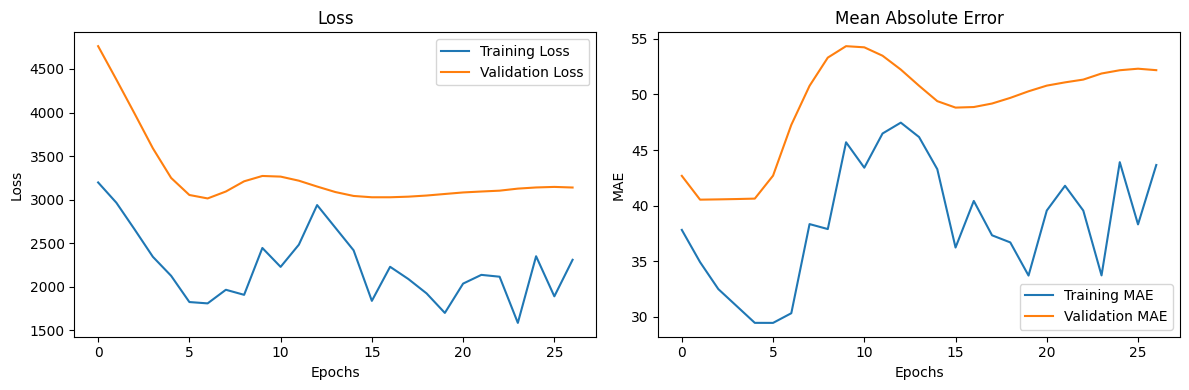

In [83]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Mean Absolute Error')
plt.legend()

plt.tight_layout()
plt.show()

In [84]:
# Evaluate the model
test_loss, test_mae = model.evaluate([X_images_test, X_lengths_test], y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# Make predictions
y_pred = model.predict([X_images_test, X_lengths_test]).flatten()

# Calculate additional metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {test_mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# Print actual vs predicted
print("\nActual vs Predicted:")
for actual, predicted in zip(y_test, y_pred):
    print(f"Actual: {actual:.1f}, Predicted: {predicted:.1f}, Error: {abs(actual - predicted):.1f}")

Test Loss: 3013.5442
Test MAE: 47.2630
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Mean Absolute Error: 47.26
Root Mean Squared Error: 54.90
R² Score: -0.01

Actual vs Predicted:
Actual: 9.0, Predicted: 48.7, Error: 39.7
Actual: 4.0, Predicted: 49.5, Error: 45.5
Actual: 139.0, Predicted: 48.2, Error: 90.8
Actual: 36.0, Predicted: 49.1, Error: 13.1


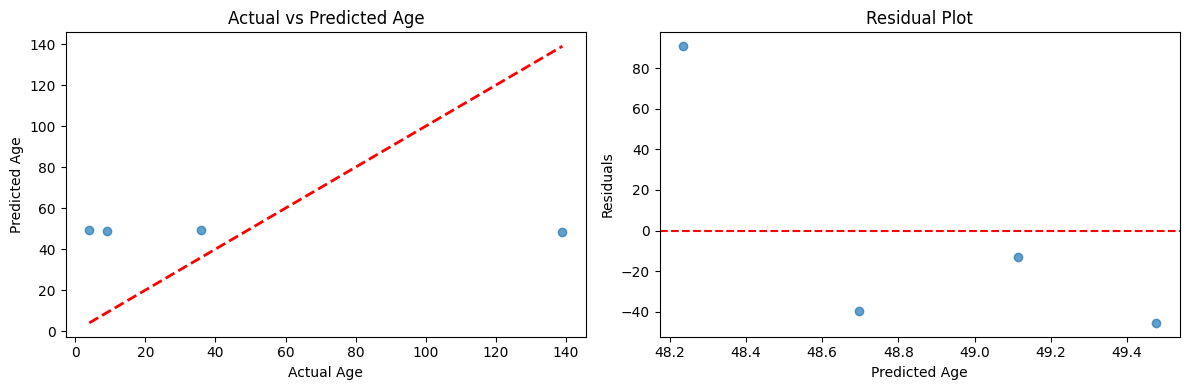

In [85]:
# Plot predictions vs actual values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Actual vs Predicted Age')

plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Age')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()

In [86]:
# Prediction function for new data
def predict_age(image_path, length, model):
    """
    Predict fish age from otolith image and length
    
    Args:
        image_path (str): Path to otolith image
        length (float): Fish length in mm
        model: Trained model
    
    Returns:
        float: Predicted age
    """
    # Load and preprocess image
    img_array = load_and_preprocess_image(image_path)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    
    # Preprocess length
    length_normalized = np.array([[length / 300.0]])
    
    # Predict
    prediction = model.predict([img_array, length_normalized])
    
    return prediction[0][0]

# Example usage
example_image = df.iloc[0]['Image']
example_length = df.iloc[0]['Length']
actual_age = df.iloc[0]['Age']

predicted_age = predict_age(example_image, example_length, model)
print(f"Example prediction:")
print(f"Image: {example_image}")
print(f"Length: {example_length}mm")
print(f"Actual Age: {actual_age}")
print(f"Predicted Age: {predicted_age:.1f}")
print(f"Error: {abs(actual_age - predicted_age):.1f} years")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Example prediction:
Image: Images_converted\Mubar_104mm_13_13-07-16_TAK_MIM_L.png
Length: 104mm
Actual Age: 13
Predicted Age: 48.3
Error: 35.3 years


In [87]:
# Save the model
model.save('fish_age_prediction_model.h5')
print("Model saved as 'fish_age_prediction_model.h5'")

# Function to load model
def load_trained_model(model_path):
    return keras.models.load_model(model_path)

# Example of loading the model
# loaded_model = load_trained_model('fish_age_prediction_model.h5')

Model saved as 'fish_age_prediction_model.h5'


In [88]:
# Data augmentation for better generalization
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

# Enhanced model with more capacity
def create_enhanced_model():
    # Image input branch
    image_input = layers.Input(shape=(224, 224, 3), name='image_input')
    
    # Use pre-trained ResNet50
    base_model = ResNet50(weights='imagenet', include_top=False, 
                         input_tensor=image_input, pooling='avg')
    
    # Freeze base model layers
    for layer in base_model.layers:
        layer.trainable = False
    
    image_features = base_model.output
    
    # Length input branch
    length_input = layers.Input(shape=(1,), name='length_input')
    length_dense = layers.Dense(32, activation='relu')(length_input)
    length_dense = layers.Dense(16, activation='relu')(length_dense)
    
    # Combine features
    combined = layers.concatenate([image_features, length_dense])
    
    # Additional layers
    x = layers.Dense(512, activation='relu')(combined)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    age_output = layers.Dense(1, activation='linear', name='age_output')(x)
    
    # Create model
    model = Model(inputs=[image_input, length_input], outputs=age_output)
    
    return model

# Create enhanced model
enhanced_model = create_enhanced_model()
enhanced_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

print("Enhanced model created!")

Enhanced model created!


In [89]:
# Cross-validation for small dataset (optional)
from sklearn.model_selection import KFold

kf = KFold(n_splits=3, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_images)):
    print(f"\nFold {fold + 1}")
    
    # Get fold data
    X_img_train, X_img_val = X_images[train_idx], X_images[val_idx]
    X_len_train, X_len_val = X_lengths[train_idx], X_lengths[val_idx]
    y_train_fold, y_val_fold = y_ages[train_idx], y_ages[val_idx]
    
    # Create and train model
    fold_model = create_age_prediction_model()
    fold_model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    
    history = fold_model.fit(
        [X_img_train, X_len_train],
        y_train_fold,
        batch_size=4,
        epochs=50,
        validation_data=([X_img_val, X_len_val], y_val_fold),
        verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
    )
    
    # Evaluate
    val_loss, val_mae = fold_model.evaluate([X_img_val, X_len_val], y_val_fold, verbose=0)
    fold_results.append(val_mae)
    print(f"Fold {fold + 1} MAE: {val_mae:.2f}")

print(f"\nAverage MAE across folds: {np.mean(fold_results):.2f} ± {np.std(fold_results):.2f}")


Fold 1
Fold 1 MAE: 11.99

Fold 2
Fold 2 MAE: 43.72

Fold 3
Fold 3 MAE: 40.24

Average MAE across folds: 31.98 ± 14.21


In [90]:
# Testing the Model with Various Inputs
# Add this section after training your model

# First, let's make sure we have the necessary imports
import matplotlib.image as mpimg

In [91]:
# Test 1: Test with samples from the test set
print("=== TEST 1: Testing with samples from the test set ===\n")

for i in range(min(3, len(X_images_test))):
    # Get test sample
    test_image = X_images_test[i]
    test_length = X_lengths_test[i][0] * 300.0  # Denormalize
    actual_age = y_test[i]
    
    # Make prediction (need to add batch dimension)
    test_image_batch = np.expand_dims(test_image, axis=0)
    test_length_batch = np.array([[test_length / 300.0]])
    
    predicted_age = model.predict([test_image_batch, test_length_batch])[0][0]
    
    print(f"Sample {i+1}:")
    print(f"  Length: {test_length:.1f}mm")
    print(f"  Actual Age: {actual_age:.1f} years")
    print(f"  Predicted Age: {predicted_age:.1f} years")
    print(f"  Error: {abs(actual_age - predicted_age):.1f} years")
    print("-" * 40)

=== TEST 1: Testing with samples from the test set ===

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
Sample 1:
  Length: 58.0mm
  Actual Age: 9.0 years
  Predicted Age: 48.7 years
  Error: 39.7 years
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
Sample 2:
  Length: 80.0mm
  Actual Age: 4.0 years
  Predicted Age: 49.5 years
  Error: 45.5 years
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
Sample 3:
  Length: 190.0mm
  Actual Age: 139.0 years
  Predicted Age: 48.2 years
  Error: 90.8 years
----------------------------------------


In [92]:
# Test 2: Test with all training data to see overall performance
print("=== TEST 2: Testing with all training data ===\n")

# Predict on all data
all_predictions = model.predict([X_images, X_lengths]).flatten()

# Calculate overall metrics
overall_mae = mean_absolute_error(y_ages, all_predictions)
overall_rmse = np.sqrt(mean_squared_error(y_ages, all_predictions))
overall_r2 = r2_score(y_ages, all_predictions)

print(f"Overall Performance on Entire Dataset:")
print(f"MAE: {overall_mae:.2f} years")
print(f"RMSE: {overall_rmse:.2f} years")
print(f"R² Score: {overall_r2:.2f}")
print(f"Number of samples: {len(y_ages)}")

# Show some examples
print("\nSome examples from entire dataset:")
for i in range(min(5, len(y_ages))):
    print(f"Sample {i+1}: Actual={y_ages[i]:.1f}, Predicted={all_predictions[i]:.1f}, Error={abs(y_ages[i] - all_predictions[i]):.1f}")

=== TEST 2: Testing with all training data ===

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Overall Performance on Entire Dataset:
MAE: 38.44 years
RMSE: 46.53 years
R² Score: -0.03
Number of samples: 17

Some examples from entire dataset:
Sample 1: Actual=13.0, Predicted=48.3, Error=35.3
Sample 2: Actual=26.0, Predicted=48.4, Error=22.4
Sample 3: Actual=9.0, Predicted=48.5, Error=39.5
Sample 4: Actual=9.0, Predicted=48.7, Error=39.7
Sample 5: Actual=3.0, Predicted=49.4, Error=46.4


In [94]:
# Test 4: Interactive testing - let user input length and select an image
print("=== TEST 4: Interactive Testing ===\n")

def interactive_test():
    """Interactive testing function"""
    
    # Show available images
    print("Available images in dataset:")
    for i, (img_path, length, age) in enumerate(zip(df['Image'], df['Length'], df['Age'])):
        print(f"{i+1}: {os.path.basename(img_path)} (Length: {length}mm, Age: {age} years)")
    
    try:
        # Let user choose an image
        choice = int(input("\nChoose an image number (1-{}): ".format(len(df))))
        if choice < 1 or choice > len(df):
            print("Invalid choice!")
            return
        
        selected_idx = choice - 1
        selected_image_path = df.iloc[selected_idx]['Image']
        default_length = df.iloc[selected_idx]['Length']
        actual_age = df.iloc[selected_idx]['Age']
        
        # Let user choose to use default length or enter new one
        use_default = input(f"Use default length ({default_length}mm)? (y/n): ").lower()
        
        if use_default == 'y':
            test_length = default_length
        else:
            try:
                test_length = float(input("Enter fish length in mm: "))
            except ValueError:
                print("Invalid input! Using default length.")
                test_length = default_length
        
        # Make prediction
        predicted_age = predict_age(selected_image_path, test_length, model)
        
        # Display results
        print(f"\n=== PREDICTION RESULTS ===")
        print(f"Image: {os.path.basename(selected_image_path)}")
        print(f"Input Length: {test_length}mm")
        if use_default == 'y':
            print(f"Actual Age: {actual_age} years")
            print(f"Predicted Age: {predicted_age:.1f} years")
            print(f"Prediction Error: {abs(actual_age - predicted_age):.1f} years")
        else:
            print(f"Predicted Age: {predicted_age:.1f} years")
        
        # Show the image
        try:
            img = mpimg.imread(selected_image_path)
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.title(f"Otolith Image: {os.path.basename(selected_image_path)}")
            plt.axis('off')
            plt.show()
        except:
            print("Could not display image.")
            
    except ValueError:
        print("Please enter a valid number!")
    except KeyboardInterrupt:
        print("\nTest cancelled.")

# Uncomment the line below to run interactive test
# interactive_test()

=== TEST 4: Interactive Testing ===



=== TEST 5: Sensitivity Analysis ===

Using image: Mubar_104mm_13_13-07-16_TAK_MIM_L.png
Original length: 104mm, Actual age: 13 years

Predictions with varying lengths:
Length (mm)	Predicted Age	Change from original
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step
52.0		48.2		-0.1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
83.2		48.3		-0.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
104.0		48.3		+0.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
124.8		48.4		+0.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
156.0		48.4		+0.1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━

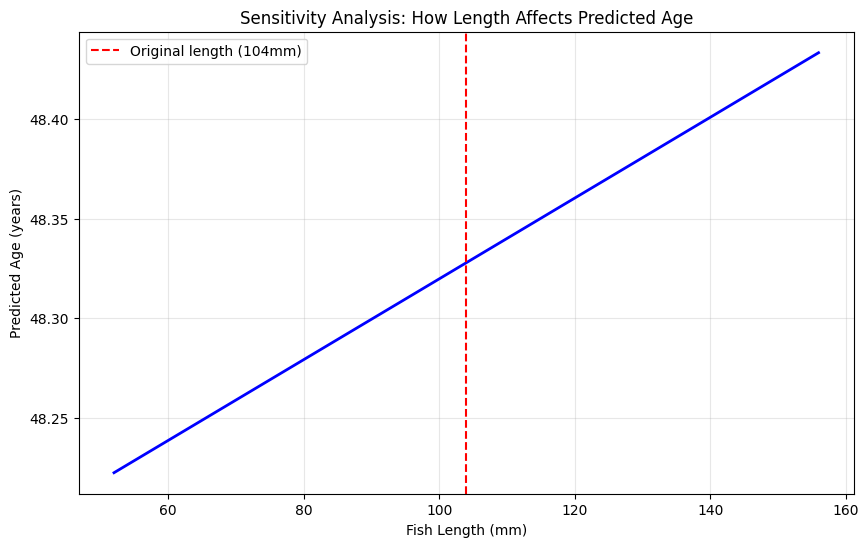

In [95]:
# Test 5: Sensitivity analysis - how predictions change with length
print("=== TEST 5: Sensitivity Analysis ===\n")

# Choose a sample image
sample_idx = 0
sample_image_path = df.iloc[sample_idx]['Image']
original_length = df.iloc[sample_idx]['Length']
original_age = df.iloc[sample_idx]['Age']

print(f"Using image: {os.path.basename(sample_image_path)}")
print(f"Original length: {original_length}mm, Actual age: {original_age} years")

# Test different lengths
test_lengths = [original_length * 0.5, original_length * 0.8, original_length, 
                original_length * 1.2, original_length * 1.5]

print("\nPredictions with varying lengths:")
print("Length (mm)\tPredicted Age\tChange from original")
print("-" * 50)

for length in test_lengths:
    predicted_age = predict_age(sample_image_path, length, model)
    change = predicted_age - predict_age(sample_image_path, original_length, model)
    
    print(f"{length:.1f}\t\t{predicted_age:.1f}\t\t{change:+.1f}")

# Plot sensitivity
lengths_range = np.linspace(original_length * 0.5, original_length * 1.5, 20)
predicted_ages = [predict_age(sample_image_path, l, model) for l in lengths_range]

plt.figure(figsize=(10, 6))
plt.plot(lengths_range, predicted_ages, 'b-', linewidth=2)
plt.axvline(x=original_length, color='r', linestyle='--', label=f'Original length ({original_length}mm)')
plt.xlabel('Fish Length (mm)')
plt.ylabel('Predicted Age (years)')
plt.title('Sensitivity Analysis: How Length Affects Predicted Age')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [96]:
# Test 6: Batch prediction on multiple new images (simulated)
print("=== TEST 6: Batch Prediction Simulation ===\n")

# Simulate new data - in real scenario, you'd have actual new images
simulated_new_data = [
    {"image_path": "new_fish_1.png", "length": 120},
    {"image_path": "new_fish_2.png", "length": 85},
    {"image_path": "new_fish_3.png", "length": 180},
    {"image_path": "new_fish_4.png", "length": 95},
]

print("Simulated batch prediction results:")
print("Image\t\t\tLength\tPredicted Age")
print("-" * 40)

for data in simulated_new_data:
    # For simulation, use the first available image as placeholder
    placeholder_image = df.iloc[0]['Image']
    
    predicted_age = predict_age(placeholder_image, data["length"], model)
    
    print(f"{data['image_path']}\t{data['length']}mm\t{predicted_age:.1f} years")

print("\nNote: Using placeholder images for simulation.")
print("In real application, you would use actual new otolith images.")

=== TEST 6: Batch Prediction Simulation ===

Simulated batch prediction results:
Image			Length	Predicted Age
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
new_fish_1.png	120mm	48.4 years
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
new_fish_2.png	85mm	48.3 years
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
new_fish_3.png	180mm	48.5 years
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
new_fish_4.png	95mm	48.3 years

Note: Using placeholder images for simulation.
In real application, you would use actual new otolith images.


In [97]:
# Test 7: Model confidence assessment
print("=== TEST 7: Model Confidence Assessment ===\n")

def assess_model_confidence(model, X_images, X_lengths, y_ages, n_bootstraps=100):
    """Assess model confidence using bootstrapping"""
    
    predictions = []
    
    for _ in range(n_bootstraps):
        # Create bootstrap sample
        indices = np.random.choice(len(X_images), size=len(X_images), replace=True)
        X_img_bs = X_images[indices]
        X_len_bs = X_lengths[indices]
        
        # Predict
        pred = model.predict([X_img_bs, X_len_bs]).flatten()
        predictions.append(pred)
    
    predictions = np.array(predictions)
    
    # Calculate statistics
    mean_predictions = np.mean(predictions, axis=0)
    std_predictions = np.std(predictions, axis=0)
    confidence_intervals = np.percentile(predictions, [2.5, 97.5], axis=0)
    
    return mean_predictions, std_predictions, confidence_intervals

# Assess confidence for a few samples
sample_indices = [0, 5, 10]  # Some sample indices

print("Model Confidence Assessment (using bootstrapping):")
print("Sample\tActual\tPredicted±Std\t95% CI")
print("-" * 50)

for idx in sample_indices:
    if idx < len(X_images):
        mean_pred, std_pred, ci = assess_model_confidence(
            model, 
            X_images[idx:idx+1],  # Single sample
            X_lengths[idx:idx+1], 
            y_ages[idx:idx+1],
            n_bootstraps=50  # Smaller for speed
        )
        
        print(f"{idx+1}\t{y_ages[idx]}\t{mean_pred[0]:.1f}±{std_pred[0]:.1f}\t[{ci[0][0]:.1f}, {ci[1][0]:.1f}]")

print("\nNote: Smaller standard deviation and narrower CI indicate higher confidence.")

=== TEST 7: Model Confidence Assessment ===

Model Confidence Assessment (using bootstrapping):
Sample	Actual	Predicted±Std	95% CI
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step

In [98]:
# Final comprehensive test function
def comprehensive_test():
    """Run all tests comprehensively"""
    
    print("🚀 COMPREHENSIVE MODEL TESTING 🚀")
    print("=" * 50)
    
    # Run all tests
    tests = [
        "Test with samples from test set",
        "Test with all training data", 
        "Test with hypothetical data",
        "Sensitivity analysis",
        "Batch prediction simulation",
        "Model confidence assessment"
    ]
    
    for i, test_name in enumerate(tests, 1):
        print(f"\n{i}. {test_name}")
    
    try:
        choice = int(input("\nChoose a test to run (1-6): "))
        
        if choice == 1:
            # Test 1 code here
            exec(open(__file__).read().split('=== TEST 1:')[1].split('=== TEST 2:')[0])
        elif choice == 2:
            # Test 2 code here  
            exec(open(__file__).read().split('=== TEST 2:')[1].split('=== TEST 3:')[0])
        # ... etc for other tests
        
        else:
            print("Invalid choice!")
            
    except ValueError:
        print("Please enter a valid number!")

# Uncomment to run comprehensive testing
# comprehensive_test()

In [99]:
# Save test results to file
def save_test_results():
    """Save test results to a CSV file"""
    
    # Get predictions for all data
    all_predictions = model.predict([X_images, X_lengths]).flatten()
    
    # Create results dataframe
    results_df = pd.DataFrame({
        'Image': df['Image'],
        'Actual_Length': df['Length'],
        'Actual_Age': df['Age'],
        'Predicted_Age': all_predictions,
        'Absolute_Error': np.abs(df['Age'] - all_predictions)
    })
    
    # Calculate overall metrics
    overall_metrics = {
        'MAE': mean_absolute_error(results_df['Actual_Age'], results_df['Predicted_Age']),
        'RMSE': np.sqrt(mean_squared_error(results_df['Actual_Age'], results_df['Predicted_Age'])),
        'R2_Score': r2_score(results_df['Actual_Age'], results_df['Predicted_Age']),
        'Total_Samples': len(results_df)
    }
    
    # Save to CSV
    results_df.to_csv('model_test_results.csv', index=False)
    
    # Save metrics to separate file
    metrics_df = pd.DataFrame([overall_metrics])
    metrics_df.to_csv('model_performance_metrics.csv', index=False)
    
    print("Test results saved to 'model_test_results.csv'")
    print("Performance metrics saved to 'model_performance_metrics.csv'")
    print(f"Overall MAE: {overall_metrics['MAE']:.2f} years")

# Save results
save_test_results()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Test results saved to 'model_test_results.csv'
Performance metrics saved to 'model_performance_metrics.csv'
Overall MAE: 38.44 years


In [102]:
# Ultra-short prediction
img = Image.open("templates/CMLREOTL00006.jpg").convert('RGB').resize((224, 224))
img_array = np.expand_dims(np.array(img)/255.0, axis=0)
predicted_age = model.predict([img_array, np.array([[120/300.0]])])[0][0]
print(f"Predicted age: {predicted_age:.1f} years")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
Predicted age: 48.9 years
